# 10 — GRU Agent: Bidirectional GRU + Temporal Attention on Engineered Features

**Why GRU over LGBM?** LightGBM treats each timestep independently — it cannot see *how* feature values evolve over time (e.g. RSI accelerating, volume trending). A GRU processes sequences and learns those dynamics directly.

**Why engineered features (not raw OHLCV)?** OHLCV-only LSTM (notebook 05) collapsed to ~0.49 constant output — too sparse a signal. The 50 RF-selected features already encode rich market structure (momentum, volatility regime, ichimoku, divergences, etc.), giving the GRU a much richer input.

**Architecture:** Bidirectional GRU → learned temporal attention (which timesteps matter?) → MLP head → P(up).

**Pipeline:**
1. Load `BTCUSDT_1h_features.parquet` + selected feature list from `local_models/lgbm_features.csv`
2. Calendar split (identical to notebook 06)
3. StandardScaler fit on train only → build (batch, SEQ_LEN, n_features) sequences
4. Train BiGRU + attention with early stopping on val loss
5. Calibration, confidence distribution, win-rate-by-bucket
6. Backtest — long + short with ATR-adaptive SL (same engine as notebook 06)
7. Compare vs buy-and-hold
8. Save model artefacts to `local_models/`

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'

TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

SEQ_LEN = 48      # 2-day lookback; features already encode longer history

# ── GRU architecture ──────────────────────────────────────────────────────────
HIDDEN_DIM  = 128
NUM_LAYERS  = 2
DROPOUT     = 0.30

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS      = 80
BATCH_SIZE  = 256
LR          = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE    = 12

# ── Trading ───────────────────────────────────────────────────────────────────
LONG_THRESHOLD        = 0.57
SHORT_THRESHOLD       = 0.43
EXIT_THRESHOLD_LONG   = 0.48
EXIT_THRESHOLD_SHORT  = 0.52

MIN_HOLD_CANDLES = 6
MAX_HOLD_CANDLES = 48
COOLDOWN_CANDLES = 3

ATR_MULTIPLIER = 2.0
MIN_SL         = 0.015
TAKE_PROFIT    = 0.03

SEED = 42

In [2]:
import json
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.calibration import calibration_curve
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()

FEATURES_DIR = REPO_ROOT / 'data' / 'features'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists():
    MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT:   {REPO_ROOT}')
print(f'MODELS_DIR:  {MODELS_DIR}')

Device: mps
REPO_ROOT:   /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR:  /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models


## 1. Load feature parquet + pre-selected features

In [3]:
FEATURES_PARQUET = FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet'
REGISTRY_PATH    = FEATURES_DIR / 'feature_registry.json'
LGBM_FEATS_PATH  = MODELS_DIR / 'lgbm_features.csv'

feat_df = pd.read_parquet(FEATURES_PARQUET)
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(REGISTRY_PATH) as f:
    registry = json.load(f)
BACKTEST_COLS = registry['backtest_only_cols']  # ['close', 'sma_200', 'atr_14_pct']

# Reuse the 50 features selected by RF + correlation filter in notebook 06
selected_features = pd.read_csv(LGBM_FEATS_PATH, header=None)[0].tolist()
# Verify all features exist in the parquet
missing = [f for f in selected_features if f not in feat_df.columns]
if missing:
    raise ValueError(f'Features missing from parquet: {missing}')

print(f'Loaded {len(feat_df):,} rows  {feat_df.index.min().date()} → {feat_df.index.max().date()}')
print(f'Using {len(selected_features)} pre-selected features (from notebook 06 RF+corr filter)')
print(f'Features: {selected_features[:10]} ... (and {len(selected_features)-10} more)')

Loaded 74,366 rows  2017-11-15 → 2026-05-16
Using 50 pre-selected features (from notebook 06 RF+corr filter)
Features: ['ret_2h', 'close_vs_ema_7', 'ret_1h', 'ret_3h', 'williams_r', 'upper_wick', 'lower_wick', 'bear_streak', 'bull_streak', 'ret_6h'] ... (and 40 more)


## 2. Calendar split

In [4]:
train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)

print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}  label={train_df["label"].mean():.3f}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}  label={val_df["label"].mean():.3f}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}  label={test_df["label"].mean():.3f}')

Train:  57,230  2017-11-15 → 2024-06-01  label=0.510
Val:     3,888  2024-06-01 → 2024-11-10  label=0.505
Test:   13,248  2024-11-10 → 2026-05-16  label=0.504


## 3. Normalize & build sequences

Each of the 50 features is **StandardScaler-normalised** using train statistics (zero-leak). 
Sequences: `X[i]` = feature matrix for timesteps `[i - SEQ_LEN, i)` → label at `i`.

In [5]:
scaler = StandardScaler()
X_train_raw = scaler.fit_transform(train_df[selected_features].values).astype(np.float32)
X_val_raw   = scaler.transform(val_df[selected_features].values).astype(np.float32)
X_test_raw  = scaler.transform(test_df[selected_features].values).astype(np.float32)

np.savez(MODELS_DIR / 'gru_scaler.npz',
         mean=scaler.mean_.astype(np.float32),
         scale=scaler.scale_.astype(np.float32))

def make_sequences(X_norm, y_raw, seq_len=SEQ_LEN):
    Xs, ys = [], []
    for i in range(seq_len, len(X_norm)):
        Xs.append(X_norm[i - seq_len : i])
        ys.append(y_raw[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train, y_train = make_sequences(X_train_raw, train_df['label'].values)
X_val,   y_val   = make_sequences(X_val_raw,   val_df['label'].values)
X_test,  y_test  = make_sequences(X_test_raw,  test_df['label'].values)

print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
print(f'  → each sample = {SEQ_LEN}h × {len(selected_features)} features')

X_train: (57182, 48, 50)  X_val: (3840, 48, 50)  X_test: (13200, 48, 50)
  → each sample = 48h × 50 features


## 4. Model: Bidirectional GRU + Temporal Attention

```
Input (B, T, F)
    ↓
BiGRU  →  (B, T, 2H)   — H=HIDDEN_DIM, forward+backward
    ↓
LayerNorm
    ↓
Temporal attention  →  scalar weight per timestep → context vector (B, 2H)
    ↓
Linear(2H→64) → GELU → Dropout → Linear(64→1) → Sigmoid
```

**Attention** learns *which hours in the lookback window matter most* — useful because a candle at hour t-2 (recent) may be more diagnostic than one at t-47 (old), and the model can adapt this per-sample.

In [6]:
class BiGRUWithAttention(nn.Module):
    """Bidirectional GRU with learned temporal attention for next-candle direction prediction."""

    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        d = hidden_dim * 2  # bidirectional doubles width
        self.norm        = nn.LayerNorm(d)
        self.attn_score  = nn.Linear(d, 1, bias=False)  # learned importance per timestep
        self.dropout     = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _  = self.gru(x)              # (B, T, 2H)
        out     = self.norm(out)
        scores  = self.attn_score(out)     # (B, T, 1)
        weights = torch.softmax(scores, dim=1)  # (B, T, 1)
        context = (out * weights).sum(dim=1)    # (B, 2H)
        context = self.dropout(context)
        return self.head(context).squeeze(-1)


model = BiGRUWithAttention(
    input_dim  = len(selected_features),
    hidden_dim = HIDDEN_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(DEVICE)

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')

BiGRUWithAttention(
  (gru): GRU(50, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (attn_score): Linear(in_features=256, out_features=1, bias=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Trainable parameters: 451,969


## 5. Training with early stopping

In [7]:
train_ds     = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds       = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5, min_lr=1e-5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')
patience_count = 0
best_state     = None
stopped_epoch  = EPOCHS

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    t_loss = t_correct = t_total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss    += loss.item() * len(xb)
        t_correct += ((preds > 0.5) == yb.bool()).sum().item()
        t_total   += len(xb)

    # ── Validate ──
    model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds   = model(xb)
            v_loss    += criterion(preds, yb).item() * len(xb)
            v_correct += ((preds > 0.5) == yb.bool()).sum().item()
            v_total   += len(xb)

    tl = t_loss / t_total;  ta = t_correct / t_total
    vl = v_loss / v_total;  va = v_correct / v_total
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    scheduler.step(vl)

    if vl < best_val_loss:
        best_val_loss  = vl
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            stopped_epoch = epoch
            print(f'Early stopping at epoch {epoch}  (best val loss: {best_val_loss:.5f})')
            break

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:>3}/{EPOCHS}  '
              f'train_loss={tl:.5f}  val_loss={vl:.5f}  '
              f'train_acc={ta:.4f}  val_acc={va:.4f}  lr={lr_now:.2e}')

model.load_state_dict(best_state)
torch.save(model.state_dict(), MODELS_DIR / 'gru_model.pt')
pd.Series(selected_features).to_csv(MODELS_DIR / 'gru_features.csv', index=False, header=False)
print(f'\nBest model saved  (val_loss={best_val_loss:.5f})')

Epoch   1/80  train_loss=0.69482  val_loss=0.69325  train_acc=0.5052  val_acc=0.5036  lr=1.00e-03
Epoch   5/80  train_loss=0.69278  val_loss=0.69358  train_acc=0.5121  val_acc=0.5031  lr=1.00e-03
Epoch  10/80  train_loss=0.68913  val_loss=0.69328  train_acc=0.5388  val_acc=0.5224  lr=5.00e-04
Early stopping at epoch 13  (best val loss: 0.69325)

Best model saved  (val_loss=0.69325)


### Training curves

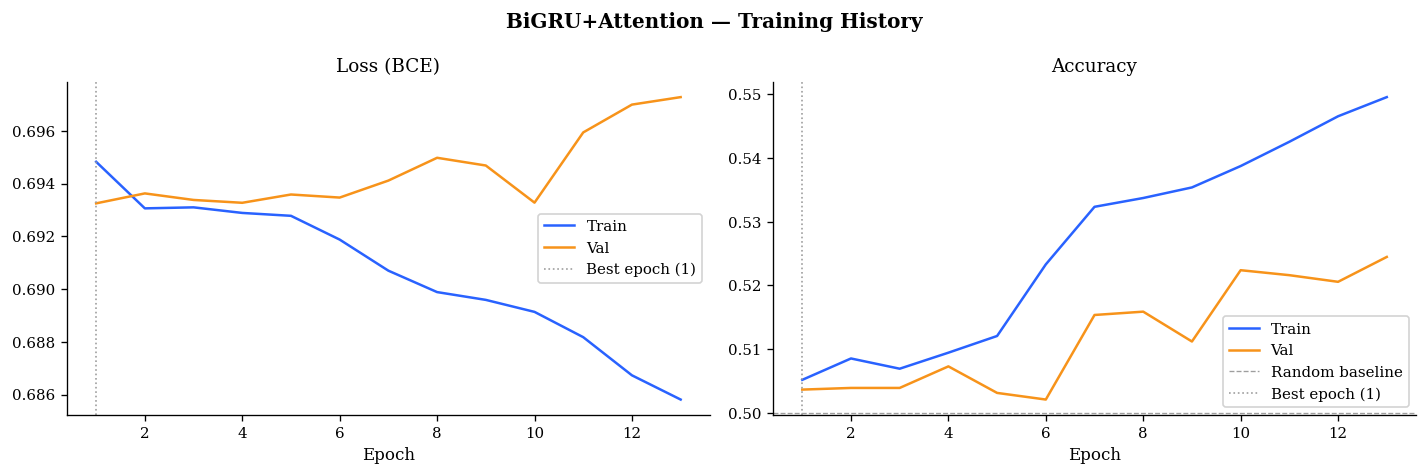

Best train acc: 0.5052
Best val acc:   0.5036
Overfitting gap: 0.0015  (ok)


In [8]:
best_epoch = stopped_epoch - patience_count
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], color=BLUE,   lw=1.5, label='Train')
ax.plot(epochs_ran, history['val_loss'],   color=ACCENT, lw=1.5, label='Val')
ax.axvline(best_epoch, color=GREY, ls=':', lw=1, label=f'Best epoch ({best_epoch})')
ax.set_title('Loss (BCE)'); ax.set_xlabel('Epoch'); ax.legend()

ax = axes[1]
ax.plot(epochs_ran, history['train_acc'], color=BLUE,   lw=1.5, label='Train')
ax.plot(epochs_ran, history['val_acc'],   color=ACCENT, lw=1.5, label='Val')
ax.axhline(0.5, color=GREY, ls='--', lw=0.8, label='Random baseline')
ax.axvline(best_epoch, color=GREY, ls=':', lw=1, label=f'Best epoch ({best_epoch})')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.legend()

fig.suptitle('BiGRU+Attention — Training History', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_training_history.png')
plt.show()

best_vi = best_epoch - 1
gap = history['train_acc'][best_vi] - history['val_acc'][best_vi]
print(f'Best train acc: {history["train_acc"][best_vi]:.4f}')
print(f'Best val acc:   {history["val_acc"][best_vi]:.4f}')
print(f'Overfitting gap: {gap:.4f}  {"(ok)" if gap < 0.05 else "(overfitting → more dropout / weight decay)"}')

## 6. Evaluation

In [9]:
model.eval()
with torch.no_grad():
    probs_val  = model(torch.from_numpy(X_val).to(DEVICE)).cpu().numpy()
    probs_test = model(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy()

val_acc  = ((probs_val  > 0.5) == y_val).mean()
test_acc = ((probs_test > 0.5) == y_test).mean()
print(f'Val  — accuracy: {val_acc:.4f}   AUC: {roc_auc_score(y_val, probs_val):.4f}')
print(f'Test — accuracy: {test_acc:.4f}   AUC: {roc_auc_score(y_test, probs_test):.4f}')
print()
print(classification_report(y_test, (probs_test > 0.5).astype(int), target_names=['down', 'up']))
print(f'Probability range: [{probs_test.min():.4f}, {probs_test.max():.4f}]  '
      f'mean={probs_test.mean():.4f}  std={probs_test.std():.4f}')

Val  — accuracy: 0.5036   AUC: 0.4996
Test — accuracy: 0.5037   AUC: 0.5052

              precision    recall  f1-score   support

        down       0.51      0.01      0.03      6553
          up       0.50      0.99      0.67      6647

    accuracy                           0.50     13200
   macro avg       0.50      0.50      0.35     13200
weighted avg       0.50      0.50      0.35     13200

Probability range: [0.4867, 0.5243]  mean=0.5130  std=0.0043


### Confidence distribution

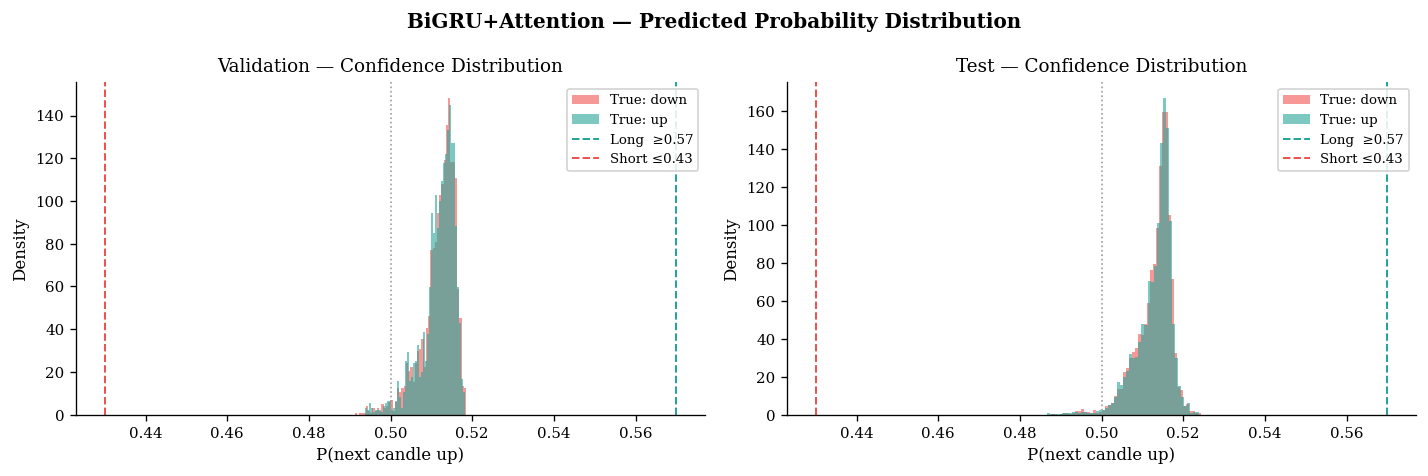

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, probs, split, y in [
    (axes[0], probs_val,  'Validation', y_val),
    (axes[1], probs_test, 'Test',       y_test),
]:
    ax.hist(probs[y == 0], bins=50, alpha=0.6, color=RED,   label='True: down', density=True)
    ax.hist(probs[y == 1], bins=50, alpha=0.6, color=GREEN, label='True: up',   density=True)
    ax.axvline(0.5,              color=GREY,  ls=':',  lw=1.0)
    ax.axvline(LONG_THRESHOLD,   color=GREEN, ls='--', lw=1.2, label=f'Long  ≥{LONG_THRESHOLD}')
    ax.axvline(SHORT_THRESHOLD,  color=RED,   ls='--', lw=1.2, label=f'Short ≤{SHORT_THRESHOLD}')
    ax.set_xlabel('P(next candle up)'); ax.set_ylabel('Density')
    ax.set_title(f'{split} — Confidence Distribution'); ax.legend(fontsize=8)
fig.suptitle('BiGRU+Attention — Predicted Probability Distribution', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_confidence_dist.png')
plt.show()

### Calibration curve

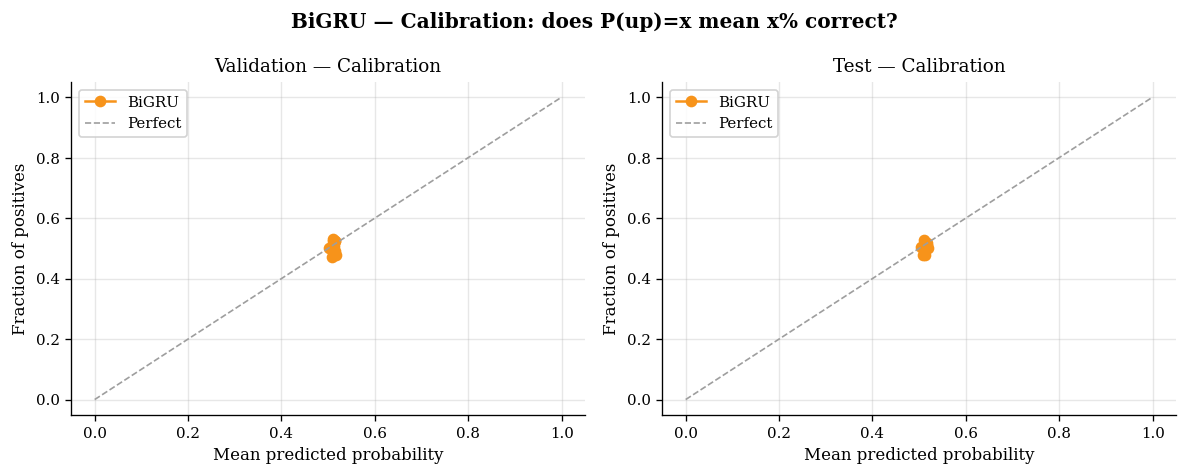

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, probs, split, y in [
    (axes[0], probs_val,  'Validation', y_val),
    (axes[1], probs_test, 'Test',       y_test),
]:
    frac_pos, mean_pred = calibration_curve(y, probs, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', color=ACCENT, lw=1.5, label='BiGRU')
    ax.plot([0, 1], [0, 1], ls='--', color=GREY, lw=1, label='Perfect')
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{split} — Calibration'); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('BiGRU — Calibration: does P(up)=x mean x% correct?', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_calibration.png')
plt.show()

### Win rate by confidence bucket

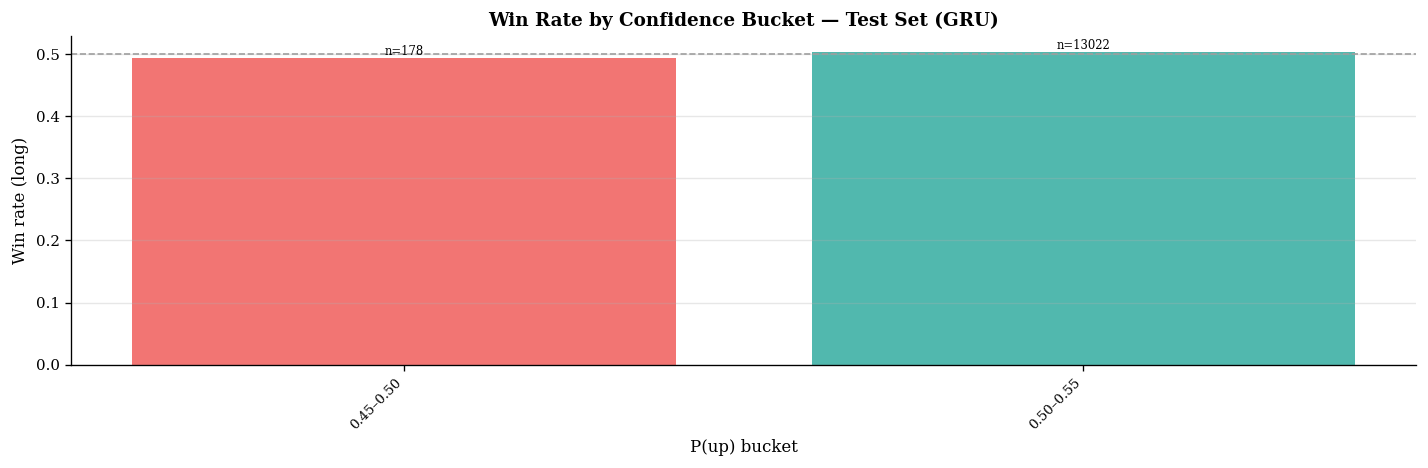

   bucket     n  win_rate_long  win_rate_short
0.45–0.50   178       0.494382        0.505618
0.50–0.55 13022       0.503686        0.496314


In [12]:
rows = []
for lo in np.arange(0.0, 1.0, 0.05):
    hi   = lo + 0.05
    mask = (probs_test >= lo) & (probs_test < hi)
    n    = mask.sum()
    if n < 10:
        continue
    rows.append({'bucket': f'{lo:.2f}–{hi:.2f}', 'n': n,
                 'win_rate_long': (y_test[mask] == 1).mean()})

bucket_df = pd.DataFrame(rows).sort_values('bucket').reset_index(drop=True)
bucket_df['win_rate_short'] = 1 - bucket_df['win_rate_long']

fig, ax = plt.subplots(figsize=(12, 4))
colors = [GREEN if r > 0.5 else RED for r in bucket_df['win_rate_long']]
ax.bar(range(len(bucket_df)), bucket_df['win_rate_long'], color=colors, alpha=0.8)
ax.axhline(0.5, color=GREY, ls='--', lw=1)
ax.set_xticks(range(len(bucket_df)))
ax.set_xticklabels(bucket_df['bucket'], rotation=45, ha='right', fontsize=8)
for i, row in bucket_df.iterrows():
    ax.text(i, row['win_rate_long'] + 0.005, f"n={row['n']}", ha='center', fontsize=7)
ax.set_xlabel('P(up) bucket'); ax.set_ylabel('Win rate (long)')
ax.set_title('Win Rate by Confidence Bucket — Test Set (GRU)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_win_rate_by_confidence.png')
plt.show()
print(bucket_df[['bucket', 'n', 'win_rate_long', 'win_rate_short']].to_string(index=False))

## 7. Backtest — Long & Short

Same engine as notebook 06. Test period uses `test_df` aligned to the SEQ_LEN offset (GRU needs SEQ_LEN past bars).

**Note:** `probs_test` is aligned to `test_df.index[SEQ_LEN:]` (first SEQ_LEN rows consumed as lookback).

In [13]:
sig_index  = test_df.index[SEQ_LEN:]
close_arr  = test_df['close'].values[SEQ_LEN:]
atr_arr    = test_df['atr_14_pct'].values[SEQ_LEN:]

assert len(sig_index) == len(probs_test), \
    f'Index mismatch: {len(sig_index)} vs {len(probs_test)}'

cash = 1.0; units = 0.0
in_pos = False; direction = None
entry_px = 0.0; entry_ts = None
entry_cash = 0.0
dynamic_sl = 0.0
hold_count = 0; cooldown = 0

equity_curve = [1.0]
trade_log    = []

for i, (ts, px, conf, atr_pct) in enumerate(
    zip(sig_index, close_arr, probs_test, atr_arr)
):
    if cooldown > 0:
        cooldown -= 1

    if in_pos:
        hold_count += 1
        pnl    = (px - entry_px) / entry_px if direction == 'long' \
                 else (entry_px - px) / entry_px
        reason = None

        if pnl <= -dynamic_sl:                                         reason = 'sl'
        elif pnl >= TAKE_PROFIT:                                       reason = 'tp'
        elif hold_count >= MAX_HOLD_CANDLES:                           reason = 'max_hold'
        elif hold_count >= MIN_HOLD_CANDLES:
            if   direction == 'long'  and conf < EXIT_THRESHOLD_LONG:  reason = 'conf'
            elif direction == 'short' and conf > EXIT_THRESHOLD_SHORT: reason = 'conf'

        if reason:
            if direction == 'long':
                cash = units * px
            else:
                cash = entry_cash * (1 + pnl)
            units = 0.0
            trade_log.append({
                'entry_time': entry_ts, 'exit_time': ts,
                'direction':  direction, 'entry_px': entry_px, 'exit_px': px,
                'pnl_pct':    pnl,       'reason':   reason,   'hold_h': hold_count,
                'dynamic_sl': dynamic_sl,
            })
            in_pos     = False; direction = None
            hold_count = 0;     cooldown  = COOLDOWN_CANDLES

    if not in_pos and cooldown == 0:
        sl = max(ATR_MULTIPLIER * atr_pct, MIN_SL)
        if conf >= LONG_THRESHOLD:
            units      = cash / px
            cash       = 0.0; in_pos = True; direction = 'long'
            entry_px   = px;  entry_ts = ts; hold_count = 0; dynamic_sl = sl
        elif conf <= SHORT_THRESHOLD:
            entry_cash = cash
            units      = cash / px
            in_pos     = True; direction = 'short'
            entry_px   = px;  entry_ts = ts; hold_count = 0; dynamic_sl = sl

    # Mark-to-market
    if in_pos and direction == 'long':
        equity_curve.append(units * px)
    elif in_pos and direction == 'short':
        equity_curve.append(entry_cash * (1 + (entry_px - px) / entry_px))
    else:
        equity_curve.append(cash)

# Force-close open position at end
if in_pos:
    px  = close_arr[-1]
    pnl = (px - entry_px) / entry_px if direction == 'long' else (entry_px - px) / entry_px
    final_cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
    trade_log.append({'entry_time': entry_ts, 'exit_time': sig_index[-1],
                      'direction': direction, 'entry_px': entry_px, 'exit_px': px,
                      'pnl_pct': pnl, 'reason': 'eod', 'hold_h': hold_count,
                      'dynamic_sl': dynamic_sl})
    equity_curve[-1] = final_cash

equity_arr = np.array(equity_curve[1:])
trades_df  = pd.DataFrame(trade_log)

print(f'Total trades: {len(trades_df)}')
if not trades_df.empty:
    print(trades_df.groupby(['direction', 'reason']).size().to_string())
    print(f'\nAvg SL used:  {trades_df["dynamic_sl"].mean()*100:.2f}%')
    print(f'Avg hold:     {trades_df["hold_h"].mean():.1f}h')

Total trades: 0


## 8. Buy-and-hold benchmark

In [14]:
bh_units  = 1.0 / close_arr[0]
bh_equity = bh_units * close_arr
bh_final  = bh_equity[-1]

## 9. Metrics

In [15]:
def sharpe(eq, ann=24 * 365):
    r = np.log(eq[1:] / (eq[:-1] + 1e-12))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(ann)) if len(r) > 1 else 0.0

def max_dd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

long_t  = trades_df[trades_df['direction'] == 'long']  if not trades_df.empty else pd.DataFrame()
short_t = trades_df[trades_df['direction'] == 'short'] if not trades_df.empty else pd.DataFrame()

metrics = pd.DataFrame([
    {'Strategy':      'BiGRU+Attention L+S',
     'Total Return':  f'{(equity_arr[-1]-1)*100:.2f}%',
     'Sharpe (ann.)': f'{sharpe(equity_arr):.3f}',
     'Max Drawdown':  f'{max_dd(equity_arr)*100:.2f}%',
     'Trades (L/S)':  f'{len(long_t)}/{len(short_t)}',
     'Win Rate':      f'{(trades_df["pnl_pct"]>0).mean()*100:.1f}%' if not trades_df.empty else 'N/A',
     'Avg Hold (h)':  f'{trades_df["hold_h"].mean():.1f}' if not trades_df.empty else 'N/A',
     'Avg SL':        f'{trades_df["dynamic_sl"].mean()*100:.2f}%' if not trades_df.empty else 'N/A',
    },
    {'Strategy':      'Buy & Hold',
     'Total Return':  f'{(bh_final-1)*100:.2f}%',
     'Sharpe (ann.)': f'{sharpe(bh_equity):.3f}',
     'Max Drawdown':  f'{max_dd(bh_equity)*100:.2f}%',
     'Trades (L/S)':  '1/0', 'Win Rate': 'N/A',
     'Avg Hold (h)':  'N/A', 'Avg SL': 'N/A',
    },
]).set_index('Strategy')
print(metrics.to_string())

                    Total Return Sharpe (ann.) Max Drawdown Trades (L/S) Win Rate Avg Hold (h) Avg SL
Strategy                                                                                             
BiGRU+Attention L+S        0.00%       -93.603        0.00%          0/0      N/A          N/A    N/A
Buy & Hold               -10.65%        -0.162      -50.08%          1/0      N/A          N/A    N/A


## 10. Results plot

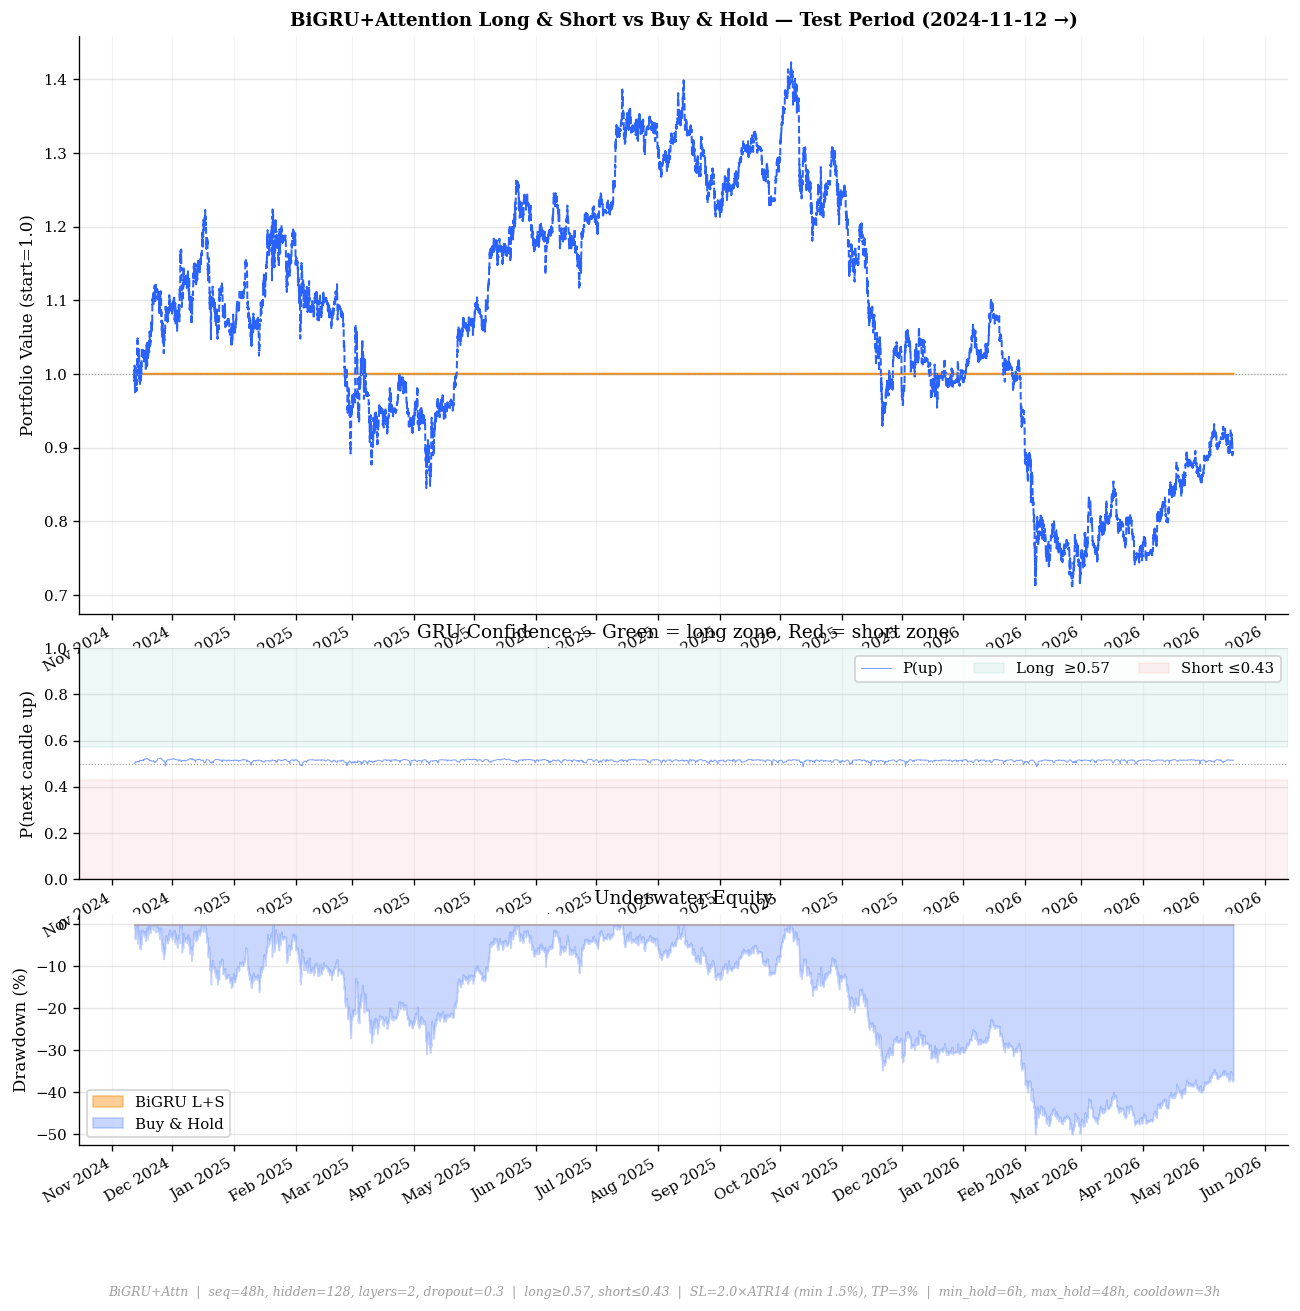

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12),
                         gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.10})

# ── Equity ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sig_index, equity_arr, color=ACCENT, lw=1.4, label='BiGRU L+S')
ax.plot(sig_index, bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
if not trades_df.empty:
    eq_s = pd.Series(equity_arr, index=sig_index)
    for _, row in trades_df.iterrows():
        ei = eq_s.index.get_indexer([row['entry_time']], method='nearest')[0]
        xi = eq_s.index.get_indexer([row['exit_time']],  method='nearest')[0]
        col = GREEN if row['direction'] == 'long' else PURPLE
        ax.scatter(eq_s.index[ei], equity_arr[ei], marker='^', color=col, s=25, zorder=5)
        ax.scatter(eq_s.index[xi], equity_arr[xi], marker='v', color=RED, s=25, zorder=5)
    from matplotlib.lines import Line2D
    handles = list(ax.get_legend_handles_labels()[0]) + [
        Line2D([0],[0], marker='^', color='w', markerfacecolor=GREEN,  markersize=8, label='Long entry'),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=PURPLE, markersize=8, label='Short entry'),
        Line2D([0],[0], marker='v', color='w', markerfacecolor=RED,    markersize=8, label='Exit'),
    ]
    ax.legend(handles=handles, ncol=3)
ax.set_ylabel('Portfolio Value (start=1.0)')
ax.set_title(f'BiGRU+Attention Long & Short vs Buy & Hold — Test Period ({sig_index.min().date()} →)',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Confidence ────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(sig_index, probs_test, color=BLUE, lw=0.6, alpha=0.6, label='P(up)')
ax.axhspan(LONG_THRESHOLD,  1.0, alpha=0.08, color=GREEN, label=f'Long  ≥{LONG_THRESHOLD}')
ax.axhspan(0.0, SHORT_THRESHOLD, alpha=0.08, color=RED,   label=f'Short ≤{SHORT_THRESHOLD}')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0, 1); ax.set_ylabel('P(next candle up)')
ax.set_title('GRU Confidence — Green = long zone, Red = short zone')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[2]
pk_l = np.maximum.accumulate(equity_arr)
pk_b = np.maximum.accumulate(bh_equity)
ax.fill_between(sig_index, (equity_arr - pk_l) / (pk_l + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='BiGRU L+S')
ax.fill_between(sig_index, (bh_equity  - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE,   alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.set_title('Underwater Equity')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'BiGRU+Attn  |  seq={SEQ_LEN}h, hidden={HIDDEN_DIM}, layers={NUM_LAYERS}, dropout={DROPOUT}  |  '
    f'long≥{LONG_THRESHOLD}, short≤{SHORT_THRESHOLD}  |  '
    f'SL={ATR_MULTIPLIER}×ATR14 (min {MIN_SL*100:.1f}%), TP={TAKE_PROFIT*100:.0f}%  |  '
    f'min_hold={MIN_HOLD_CANDLES}h, max_hold={MAX_HOLD_CANDLES}h, cooldown={COOLDOWN_CANDLES}h',
    ha='center', fontsize=7.5, color=GREY, style='italic')

fig.savefig(FIGURES_DIR / 'gru_backtest_results.png')
plt.show()

## 11. Trade log

In [17]:
if trades_df.empty:
    print('No trades. Try lowering LONG_THRESHOLD / raising SHORT_THRESHOLD.')
    print(f'Current P(up) range: [{probs_test.min():.4f}, {probs_test.max():.4f}]')
    print(f'Fraction above {LONG_THRESHOLD}: {(probs_test >= LONG_THRESHOLD).mean()*100:.1f}%')
    print(f'Fraction below {SHORT_THRESHOLD}: {(probs_test <= SHORT_THRESHOLD).mean()*100:.1f}%')
else:
    from IPython.display import display
    trades_df['pnl_fmt'] = trades_df['pnl_pct'].apply(lambda x: f'{x*100:+.2f}%')
    trades_df['sl_fmt']  = trades_df['dynamic_sl'].apply(lambda x: f'{x*100:.2f}%')
    display(trades_df[['entry_time', 'exit_time', 'direction', 'hold_h',
                        'entry_px', 'exit_px', 'pnl_fmt', 'sl_fmt', 'reason']])

No trades. Try lowering LONG_THRESHOLD / raising SHORT_THRESHOLD.
Current P(up) range: [0.4867, 0.5243]
Fraction above 0.57: 0.0%
Fraction below 0.43: 0.0%


## 12. Strategy summary

In [18]:
if trades_df.empty:
    print('No trades — cannot produce summary.')
    print('Adjust thresholds based on the P(up) distribution shown above.')
else:
    pnl      = trades_df['pnl_pct']
    long_t   = trades_df[trades_df['direction'] == 'long']
    short_t  = trades_df[trades_df['direction'] == 'short']
    winning  = trades_df[pnl > 0]
    losing   = trades_df[pnl <= 0]
    pnl_pct  = pnl * 100

    print('=' * 60)
    print('  STRATEGY SUMMARY — BiGRU+Attention Long & Short')
    print('=' * 60)

    print('\n── Trade counts ──────────────────────────────────────────')
    print(f'  Total trades   : {len(trades_df)}')
    print(f'    Long         : {len(long_t)}')
    print(f'    Short        : {len(short_t)}')
    print(f'  Winning        : {len(winning)}  ({len(winning)/len(trades_df)*100:.1f}%)')
    print(f'  Losing         : {len(losing)}  ({len(losing)/len(trades_df)*100:.1f}%)')

    print('\n── Exit reasons ──────────────────────────────────────────')
    for reason, grp in trades_df.groupby('reason'):
        wr = (grp['pnl_pct'] > 0).mean() * 100
        print(f'  {reason:<12}  n={len(grp):>3}  win_rate={wr:.1f}%  '
              f'avg_pnl={grp["pnl_pct"].mean()*100:+.2f}%')

    print('\n── Return percentiles (% per trade) ─────────────────────')
    for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        print(f'  p{p:<11}  {pnl_pct.quantile(p/100):>+7.2f}%')
    print(f'  {"mean":<12}  {pnl_pct.mean():>+7.2f}%')
    print(f'  {"std":<12}  {pnl_pct.std():>7.2f}%')

    print('\n── Hold duration (hours) ─────────────────────────────────')
    print(f'  Mean           : {trades_df["hold_h"].mean():.1f}h')
    print(f'  Median         : {trades_df["hold_h"].median():.1f}h')
    print(f'  Min / Max      : {trades_df["hold_h"].min()}h / {trades_df["hold_h"].max()}h')

    print('\n── Portfolio result ──────────────────────────────────────')
    print(f'  Final equity        : {equity_arr[-1]:.4f}  (started at 1.0000)')
    print(f'  Total return        : {(equity_arr[-1] - 1)*100:+.2f}%')
    print(f'  Buy-and-hold return : {(bh_final - 1)*100:+.2f}%')
    print(f'  Alpha               : {(equity_arr[-1] - bh_final)*100:+.2f}pp')
    print(f'  Sharpe (ann.)       : {sharpe(equity_arr):.3f}')
    print(f'  Max drawdown        : {max_dd(equity_arr)*100:.2f}%')
    print('=' * 60)

No trades — cannot produce summary.
Adjust thresholds based on the P(up) distribution shown above.


## 13. Attention weight visualisation

Which positions in the 48-hour lookback window does the model attend to most? Averaged over the test set.

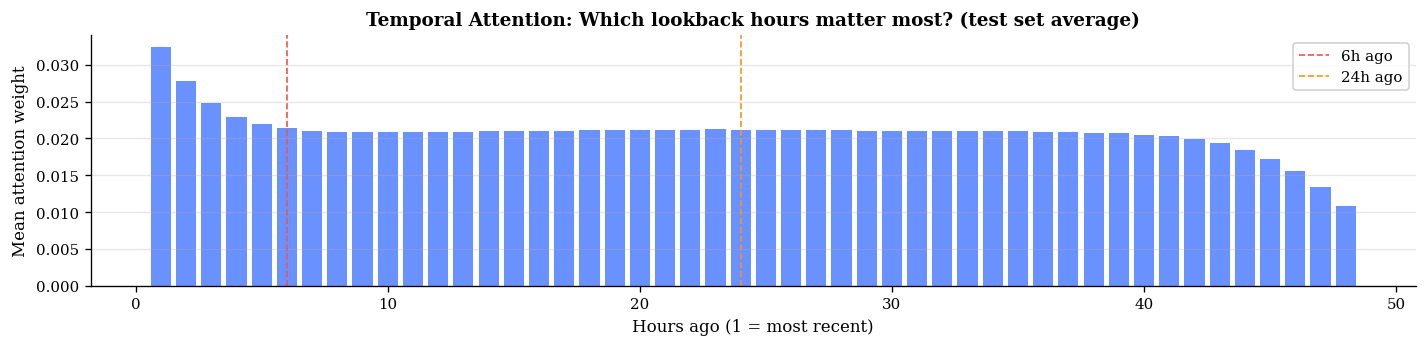

Peak attention at 1h ago  (weight=0.0324)


In [19]:
model.eval()
all_weights = []
# Compute attention weights in batches to avoid OOM
test_tensor = torch.from_numpy(X_test)
with torch.no_grad():
    for start in range(0, len(test_tensor), BATCH_SIZE):
        xb  = test_tensor[start:start + BATCH_SIZE].to(DEVICE)
        out, _ = model.gru(xb)
        out = model.norm(out)
        scores  = model.attn_score(out)             # (B, T, 1)
        weights = torch.softmax(scores, dim=1)      # (B, T, 1)
        all_weights.append(weights.squeeze(-1).cpu().numpy())

attn_mean = np.concatenate(all_weights, axis=0).mean(axis=0)  # (SEQ_LEN,)

fig, ax = plt.subplots(figsize=(12, 3))
hours_ago = np.arange(SEQ_LEN, 0, -1)
ax.bar(hours_ago, attn_mean[::-1], color=BLUE, alpha=0.7)
ax.set_xlabel('Hours ago (1 = most recent)')
ax.set_ylabel('Mean attention weight')
ax.set_title('Temporal Attention: Which lookback hours matter most? (test set average)',
             fontweight='bold')
ax.axvline(6,  color=RED,   ls='--', lw=1, label='6h ago')
ax.axvline(24, color=ACCENT,ls='--', lw=1, label='24h ago')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gru_attention_weights.png')
plt.show()
print(f'Peak attention at {hours_ago[np.argmax(attn_mean[::-1])]}h ago  '
      f'(weight={attn_mean.max():.4f})')

## 14. Next steps

If the model generates sufficient signals, run a grid search over trading parameters (analogous to notebook 07/08) to optimise thresholds for this model's output distribution.

Key levers to tune:
- `LONG_THRESHOLD` / `SHORT_THRESHOLD` — should match this model's actual P(up) spread (see win-rate-by-bucket)
- `SEQ_LEN` — try 24h (less history) or 72h (more)
- `HIDDEN_DIM` / `NUM_LAYERS` — scale up if val acc is still improving
- Label smoothing or focal loss if the model outputs flat probabilities
- Ensemble with LGBM: average GRU + LGBM probs for a combined signal